# GraphServe: inference engineering evidence report

Offline analysis of saved experiments. Historical shared-RayService measurements are kept separate from the current explicit orchestration path. Missing evidence is labeled rather than inferred. No cell deploys resources or calls a hosted model.

## Current system and experiment boundaries

The control node hosts nginx, the Python agent and gateway, two Ray heads, and monitoring. Hosted Superlinked SIE provides embeddings for reranking. Two GPU workers each run a complete Qwen2.5-Coder-7B-Instruct BF16 replica.

User → nginx → agent authentication → Graphify retrieval → hosted SIE → token-aware context → internal nginx → guard/admission → worker placement → bounded priority queue → Ray Serve/vLLM → source verification.

Final profiles use two stable RayServices. Engine settings: BF16, tensor parallel size 1, context length 8192, memory utilization budget 0.9, maximum sequences 8. Baseline disables prefix caching; comparison enables it. Gateway dispatch concurrency is 4 per worker with 8 waiting slots. These are repository settings, not independently captured effective runtime settings for every saved run.

Historical A/B below changed BOTH caching and Ray routing. They cannot isolate the effect of prefix caching. The analyzed class9 repository is the question corpus, not the GraphServe serving implementation.

In [1]:
from pathlib import Path
import json, math, html
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd()
if not (ROOT / "benchmarks").exists() and (ROOT.parent / "benchmarks").exists():
    ROOT = ROOT.parent
if not (ROOT / "benchmarks").exists():
    raise FileNotFoundError("Run this notebook from the GraphServe repository root")

CONFIGS = {
    "A — default": ROOT / "benchmarks/config-a-multinode-default",
    "B — prefix affinity": ROOT / "benchmarks/config-b-multinode-prefix-aware",
}
summaries = {name: json.loads((path / "summary.json").read_text()) for name, path in CONFIGS.items()}
requests = {name: [json.loads(line) for line in (path / "requests.jsonl").read_text().splitlines()]
            for name, path in CONFIGS.items()}
print("Loaded:", ", ".join(f"{name} ({len(requests[name])} records)" for name in CONFIGS))

Loaded: A — default (38 records), B — prefix affinity (38 records)


## Historical shared-RayService A/B results

These October 1 measurements predate explicit gateway orchestration. Latency and throughput count successful requests; read failures alongside them.

In [2]:
rows = []
for name, summary in summaries.items():
    for phase in summary["phases"]:
        rows.append({"config": name, **phase})

lines = []
lines.append("| Configuration | C | Success | Requests/s | p50 (s) | p95 (s) | Tokens/s |")
lines.append("|---|---:|---:|---:|---:|---:|---:|")
for row in rows:
    lines.append(f"| {row['config']} | {row['concurrency']} | {row['successful']}/{row['requests']} | "
          f"{row['request_throughput_per_s']:.3f} | {row['latency_p50_s']:.2f} | "
          f"{row['latency_p95_s']:.2f} | {row['total_tokens_per_s']:.0f} |")
display(Markdown("\n".join(lines)))


| Configuration | C | Success | Requests/s | p50 (s) | p95 (s) | Tokens/s |
|---|---:|---:|---:|---:|---:|---:|
| A — default | 1 | 12/12 | 0.138 | 6.38 | 11.13 | 738 |
| A — default | 2 | 12/12 | 0.285 | 6.46 | 10.73 | 1524 |
| A — default | 4 | 12/12 | 0.492 | 6.62 | 12.06 | 2633 |
| B — prefix affinity | 1 | 12/12 | 0.143 | 6.15 | 10.75 | 765 |
| B — prefix affinity | 2 | 12/12 | 0.272 | 5.78 | 13.41 | 1459 |
| B — prefix affinity | 4 | 8/12 | 0.038 | 43.60 | 80.92 | 199 |

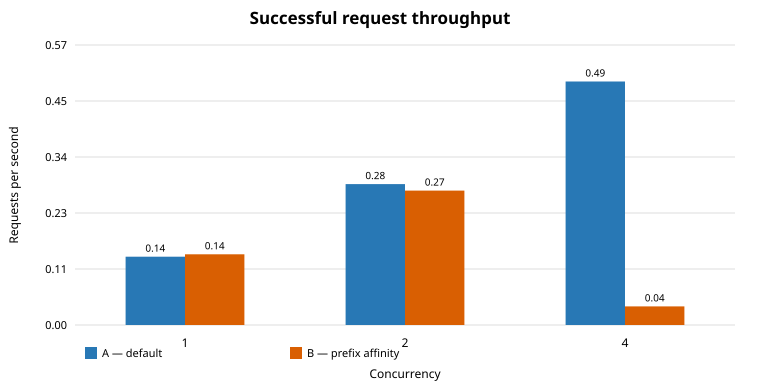

In [3]:
COLORS = {"A — default": "#2878B5", "B — prefix affinity": "#D95F02"}

def grouped_svg(metric, title, ylabel, width=760, height=390):
    concurrencies = [1, 2, 4]
    names = list(CONFIGS)
    vals = {(r["config"], r["concurrency"]): float(r[metric]) for r in rows}
    top = max(vals.values()) * 1.15 or 1
    left, right, upper, bottom = 75, 25, 45, 65
    plot_w, plot_h = width-left-right, height-upper-bottom
    p = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
         '<rect width="100%" height="100%" fill="white"/>',
         f'<text x="{width/2}" y="24" text-anchor="middle" font-family="sans-serif" font-size="17" font-weight="bold">{html.escape(title)}</text>']
    for i in range(6):
        v, y = top*i/5, upper+plot_h-plot_h*i/5
        p += [f'<line x1="{left}" x2="{left+plot_w}" y1="{y:.1f}" y2="{y:.1f}" stroke="#ddd"/>',
              f'<text x="{left-8}" y="{y+4:.1f}" text-anchor="end" font-family="sans-serif" font-size="11">{v:.2f}</text>']
    group_w, bar_w = plot_w/len(concurrencies), plot_w/len(concurrencies)*0.27
    for gi, c in enumerate(concurrencies):
        center = left+group_w*(gi+0.5)
        for ni, name in enumerate(names):
            value = vals[(name, c)]; bar_h = value/top*plot_h
            x = center+(ni-0.5)*bar_w-bar_w/2; y = upper+plot_h-bar_h
            p += [f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_w:.1f}" height="{bar_h:.1f}" fill="{COLORS[name]}"/>',
                  f'<text x="{x+bar_w/2:.1f}" y="{max(upper+10,y-5):.1f}" text-anchor="middle" font-family="sans-serif" font-size="10">{value:.2f}</text>']
        p.append(f'<text x="{center:.1f}" y="{upper+plot_h+22}" text-anchor="middle" font-family="sans-serif" font-size="12">{c}</text>')
    p += [f'<text x="{left+plot_w/2}" y="{height-12}" text-anchor="middle" font-family="sans-serif" font-size="12">Concurrency</text>',
          f'<text transform="translate(18 {upper+plot_h/2}) rotate(-90)" text-anchor="middle" font-family="sans-serif" font-size="12">{html.escape(ylabel)}</text>']
    for i, name in enumerate(names):
        p += [f'<rect x="{left+10+i*205}" y="{height-43}" width="12" height="12" fill="{COLORS[name]}"/>',
              f'<text x="{left+27+i*205}" y="{height-33}" font-family="sans-serif" font-size="11">{html.escape(name)}</text>']
    return ''.join(p+['</svg>'])

display(SVG(grouped_svg("request_throughput_per_s", "Successful request throughput", "Requests per second")))

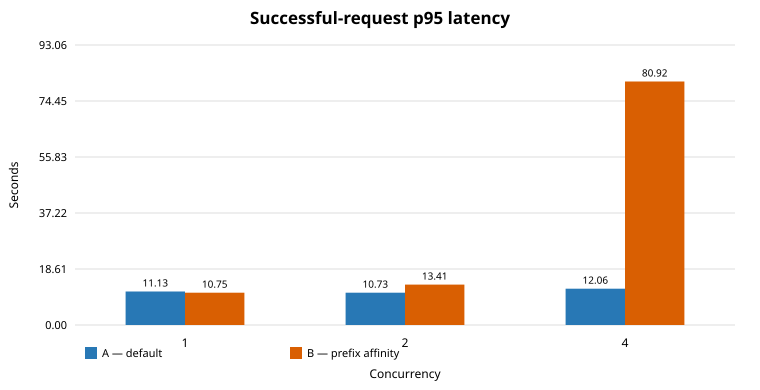

In [4]:
display(SVG(grouped_svg("latency_p95_s", "Successful-request p95 latency", "Seconds")))

## Serving telemetry

These are maxima observed in each saved Prometheus range. TTFT is an aggregate histogram estimate, not a per-request timestamp. A value of 100% GPU utilization is a sampled peak, not a phase average.

In [5]:
def metric_max(config_path, concurrency, key):
    payload = json.loads((config_path / f"metrics-c{concurrency}.json").read_text())
    values = []
    for series in payload.get(key, {}).get("result", []):
        for _, raw in series.get("values", []):
            try: value = float(raw)
            except (TypeError, ValueError): continue
            if math.isfinite(value): values.append(value)
    return max(values) if values else None

lines = []
lines.append("| Configuration | C | max aggregate TTFT p95 (s) | max KV use | max Serve queue | max GPU use |")
lines.append("|---|---:|---:|---:|---:|---:|")
for name, path in CONFIGS.items():
    for c in (1, 2, 4):
        ttft = metric_max(path, c, "ttft_p95")
        kv = metric_max(path, c, "kv_cache")
        queue = metric_max(path, c, "serve_queued")
        gpu = metric_max(path, c, "gpu_utilization")
        lines.append(f"| {name} | {c} | {ttft:.3f} | {kv*100:.2f}% | {queue:.0f} | {gpu:.0f}% |")
display(Markdown("\n".join(lines)))


| Configuration | C | max aggregate TTFT p95 (s) | max KV use | max Serve queue | max GPU use |
|---|---:|---:|---:|---:|---:|
| A — default | 1 | 0.959 | 1.13% | 0 | 100% |
| A — default | 2 | 0.488 | 0.89% | 0 | 100% |
| A — default | 4 | 0.488 | 1.11% | 0 | 100% |
| B — prefix affinity | 1 | 0.948 | 1.54% | 0 | 100% |
| B — prefix affinity | 2 | 0.485 | 1.54% | 0 | 100% |
| B — prefix affinity | 4 | 0.444 | 1.13% | 3 | 100% |

## Failure evidence

Failures remain in `requests.jsonl`; they are not included in successful-request latency percentiles.

In [6]:
failures = [(name, row) for name, records in requests.items() for row in records
            if row.get("phase") != "warmup" and not row.get("ok")]
print(f"Measured failures: {len(failures)}")
for name, row in failures:
    print(f"- {name}: seq={row['sequence']} phase={row['phase']} status={row['status_code']} "
          f"latency={row['latency_s']:.2f}s — {row['question']}")

Measured failures: 4
- B — prefix affinity: seq=26 phase=c4 status=502 latency=124.70s — Trace a text request from the gateway through routing, worker selection, and completion.
- B — prefix affinity: seq=28 phase=c4 status=502 latency=125.66s — Explain how prefill and decode KV transfer works with Mooncake.
- B — prefix affinity: seq=29 phase=c4 status=502 latency=124.65s — How does the planner decide whether to add prefill or decode replicas?
- B — prefix affinity: seq=30 phase=c4 status=502 latency=122.76s — Propose adding a circuit breaker to overflow calls. Name the files and tests to change.


## Historical interpretation

The historical B run has four concurrency-4 failures. It changed caching and routing together, so it does not establish which caused the result. Preserve this evidence, but use identical final gateway policy for the next controlled A/B experiment.

## Reproducibility checks

In [7]:
assert [p["successful"] for p in summaries["A — default"]["phases"]] == [12, 12, 12]
assert [p["successful"] for p in summaries["B — prefix affinity"]["phases"]] == [12, 12, 8]
assert len(failures) == 4 and all(row["status_code"] == 502 for _, row in failures)
assert "enable_prefix_caching: false" in (CONFIGS["A — default"] / "rayservice.yaml").read_text()
assert "enable_prefix_caching: true" in (CONFIGS["B — prefix affinity"] / "rayservice.yaml").read_text()
print("Evidence assertions passed: summaries, failures, and serving manifests agree.")

Evidence assertions passed: summaries, failures, and serving manifests agree.


## Historical evidence limits

One run per profile; no isolated prefix workload; non-streaming requests; no semantic answer scoring. The following sections analyze newer orchestration evidence separately.

## Current live gateway smoke evidence

Collected independently from the application stress run. Short direct gateway calls demonstrate integration, not sustained capacity. Same-worker affinity is not proof of a cache hit; batch acceptance is not proof of priority ordering.

In [8]:
EVIDENCE = ROOT / "benchmarks/submission-evidence"
smoke = json.loads((EVIDENCE / "orchestration-smoke.json").read_text())
print("Collected:", smoke.get("started_at"))
lines = ["| Live check | Result |", "|---|---|"]
for check in smoke["checks"]:
    lines.append(f"| {check['name']} | {'PASS' if check['passed'] else 'FAIL'} |")
display(Markdown("\n".join(lines)))
print(json.dumps(smoke.get("affinity"), indent=2))


Collected: 2026-10-07T04:49:17.285364+00:00
{
  "first": {
    "x-graphserve-request-id": "211d4e96b6bc471cbcf427a94b9cc698",
    "x-graphserve-worker": "a",
    "x-graphserve-placement": "least_loaded",
    "x-graphserve-hop": "cold_start",
    "x-graphserve-queue-wait-ms": "0.17"
  },
  "second": {
    "x-graphserve-request-id": "59bc128234d1498e8f2eda0aa9e3a16c",
    "x-graphserve-worker": "a",
    "x-graphserve-placement": "prefix_affinity",
    "x-graphserve-hop": "same_worker",
    "x-graphserve-queue-wait-ms": "0.19"
  }
}


| Live check | Result |
|---|---|
| two healthy stable workers | PASS |
| invalid JSON | PASS |
| wrong model | PASS |
| streaming disabled | PASS |
| context budget | PASS |
| invalid priority | PASS |
| affinity requests succeed | PASS |
| first request is cold | PASS |
| repeat stays on worker | PASS |
| unique prefixes reach both workers | PASS |
| batch priority accepted | PASS |
| orchestration metrics exposed | PASS |

## Deterministic gateway policy tests

Local tests use controlled queues and mocked engine responses. They cover guard rejection, tenant admission, bounded queues, dispatch metadata, 503 retry preservation, and interactive-before-batch ordering. They do not establish live worker-failure recovery.

In [9]:
import xml.etree.ElementTree as ET
cases = ET.parse(EVIDENCE / "gateway-tests.xml").findall(".//testcase")
lines = ["| Policy test | Result |", "|---|---|"]
for case in cases:
    result = "FAIL" if case.find("failure") is not None or case.find("error") is not None else ("SKIP" if case.find("skipped") is not None else "PASS")
    lines.append(f"| {case.attrib['name']} | {result} |")
display(Markdown("\n".join(lines)))


| Policy test | Result |
|---|---|
| test_named_guard_rejects_before_admission | PASS |
| test_admission_affinity_and_bounded_queues | PASS |
| test_tenant_token_window | PASS |
| test_dispatch_records_worker_and_preserves_status | PASS |
| test_dispatch_preserves_engine_overflow_metadata | PASS |
| test_interactive_priority_runs_before_queued_batch | PASS |

## Current orchestrated run: admission-limited traffic

This is a single baseline-labeled run, not a final A/B comparison. Adjacent phases share the repository tenant token window. Rejections therefore confound a concurrency/capacity comparison. The directory does not contain a contemporaneous deployment manifest or environment capture, so the runtime configuration is not independently verified.

In [10]:
current_path = ROOT / "benchmarks/config-a-orchestrated/run-1"
current = json.loads((current_path / "summary.json").read_text())
current_requests = [json.loads(line) for line in (current_path / "requests.jsonl").read_text().splitlines() if line.strip()]
measured = [r for r in current_requests if r.get("phase") != "warmup"]
from collections import Counter
print("UTC start:", current["started_at"], "Repository:", current["repository_id"], "Scope:", current["scope"])
lines = ["| C | Success / total | Statuses | Success/s | Success p95 seconds | Queue p95 ms | Workers |", "|---|---|---|---|---|---|---|"]
for p in current["phases"]:
    serving = p.get("serving", {})
    lines.append(f"| {p['concurrency']} | {p['successful']}/{p['requests']} | {p['status_counts']} | {p['request_throughput_per_s']:.3f} | {p['latency_p95_s']:.3f} | {serving.get('queue_wait_p95_ms')} | {serving.get('workers')} |")
display(Markdown("\n".join(lines)))
rejections = Counter(str(r.get("response", {}).get("detail")) for r in measured if not r.get("ok"))
print("Observed rejection reasons:", dict(rejections))
print("Retry-After values:", dict(Counter((r.get("response_headers") or {}).get("retry-after", "missing") for r in measured if not r.get("ok"))))
for p in current["phases"]:
    records = [r for r in measured if r["phase"] == f"c{p['concurrency']}"]
    assert len(records) == p["requests"]
    assert sum(bool(r.get("ok")) for r in records) == p["successful"]


UTC start: 2026-10-07T04:49:45.802988+00:00 Repository: 46104a869aaa639f02058087 Scope: class9
Observed rejection reasons: {'tenant_tokens': 23}
Retry-After values: {'5': 3, '3': 8, '1': 4, '7': 2, '2': 3, '4': 3}


| C | Success / total | Statuses | Success/s | Success p95 seconds | Queue p95 ms | Workers |
|---|---|---|---|---|---|---|
| 1 | 8/12 | {'200': 8, '429': 4} | 0.156 | 9.574 | 0.1765 | {'b': 8} |
| 2 | 3/12 | {'429': 9, '200': 3} | 0.204 | 4.525 | 0.223 | {'b': 3} |
| 4 | 2/12 | {'429': 10, '200': 2} | 0.127 | 11.527 | 0.169 | {'b': 2} |

The saved run has 13 successful and 23 rejected measured requests. All recorded rejection details are `tenant_tokens`. Successful final-response serving metadata reports worker b and same-worker affinity. Low queue wait in these successes does not demonstrate queue saturation or balanced use of both GPUs. A smaller p95 with fewer successes does not establish an improvement. Final-response metadata can also omit earlier attempts when an answer was retried.

## Example application response and source boundary

The following is an actual saved response. This checks returned source paths and displays claim citations, but does not independently re-fetch Git blobs or score semantic correctness. The ingestion request/full pinned SHA still needs its own saved artifact.

In [11]:
example = next(r for r in measured if r.get("ok") and r.get("response", {}).get("sources"))
print("Question:", example["question"])
body = example["response"]
print("Mode:", body.get("mode"), "Verification:", body.get("verification"))
for claim in body.get("answer", {}).get("claims", []):
    print("CLAIM:", claim.get("text"), "CITATIONS:", claim.get("citations"))
for source in body["sources"]:
    print(source.get("id"), source.get("path"), source.get("start"), source.get("end"))
paths = [s["path"] for r in measured if r.get("ok") for s in r.get("response", {}).get("sources", [])]
assert paths and all(p.startswith("class9/") for p in paths)
print("Observed scope check passed for", len(paths), "returned excerpts.")
proposals = [r for r in measured if r.get("ok") and r.get("response", {}).get("answer", {}).get("proposal")]
print("Successful responses with proposals:", len(proposals))
if proposals:
    print(json.dumps(proposals[0]["response"]["answer"]["proposal"], indent=2))
print("Manual correctness/citation assessment: NOT COLLECTED")


Question: Trace a text request from the gateway through routing, worker selection, and completion.
Mode: real Verification: Source IDs, blob contents and line ranges verified; semantic entailment is not guaranteed.
CLAIM: The text request starts at the gateway's serve.py file. CITATIONS: ['S5']
CLAIM: The request is then routed by the router module. CITATIONS: ['S3']
CLAIM: Worker selection occurs within the router module based on the request's capabilities. CITATIONS: ['S3']
S5 class9/gateway/serve.py 1 63
S3 class9/gateway/admission.py 12 43
S8 class9/tests/test_bind_capability.py 1 34
S9 class9/app.py 1 25
S1 class9/tests/test_bind_capability.py 63 103
S2 class9/app.py 473 497
S6 class9/app.py 425 449
S7 class9/gateway/admission.py 62 70
S4 class9/gateway/metrics.py 9 49
Observed scope check passed for 125 returned excerpts.
Successful responses with proposals: 11
[
  {
    "text": "The current implementation correctly handles both 429 and 503/529 responses by routing them appropria

## Requirement-to-evidence assessment

| Requirement | Evidence/status | Remaining evidence |
|---|---|---|
| Pinned ingestion | Partial: repository ID in saved requests | Save ingestion URL/full SHA and commit-linked citation |
| Architecture and change questions | Saved answers/proposals displayed | Manual correctness and change-impact review |
| Unsupported question | Not demonstrated | Dedicated absent-functionality case and review |
| Retrieval boundary | Observed class9 source-path check | Saved invalid-scope rejection |
| Guard | Live smoke and deterministic tests | GPU non-dispatch correlation if required |
| Admission | Live tenant_tokens rejections with retry guidance | Isolate tenant, deadline and KV policies |
| Two-worker placement | Live smoke reaches a and b | Pod/node mapping and load-override trace |
| Bounded queue | Deterministic test | Live saturation and queue_full evidence |
| Priority | Deterministic ordering test | Controlled live dispatch trace |
| Prefix affinity/hops | Live same-worker; controlled queue relocation | Live cold-recompute and actual engine cache hits |
| Overflow | Mocked 503 stay/retry test | 529 and live injected failure evidence |
| Cancellation/recovery | Not demonstrated here | Cancellation and worker recovery timeline |
| Two vLLM configurations | Historical A/B measured; current A only | Final controlled A/B, repeated runs, runtime captures |
| Quality | Not scored | Frozen questions, expected sources and reviewer scores |
| Streaming TTFT | Not implemented in application path | Per-request first-content-token timestamps |
| Reproducibility | Offline artifact-based notebook | Final evidence, executed notebook and reviewed PDF |

Missing telemetry is unavailable, not zero. Same-worker routing does not prove cache reuse. No cross-node KV transfer or external overflow destination is claimed.


## Collect and reproduce

Run from the repository root. No live cluster is needed to execute this notebook.

```bash
.venv/bin/python -m pytest -v tests/test_gateway.py --junitxml=benchmarks/submission-evidence/gateway-tests.xml
make orchestration-smoke CONTROL_HOST=CONTROL_PUBLIC_IP
# Review and copy the smoke report into benchmarks/submission-evidence/.
```

For final A/B: save the actual deployed manifests, image/model revisions, GPU/node mapping, test code commit, workload and timestamps alongside raw requests and Prometheus ranges. Use identical traffic and gateway settings; isolate prefix reuse and use repeated runs. Separate tenant-limit experiments from engine-capacity measurements. Account for the 60-second tenant window between phases.

Execute all cells in Jupyter from the repository root and save outputs. Export and review the PDF after the remaining evidence is collected. This notebook is an interim evidence report, not a claim that every requirement is complete.
